<a href="https://colab.research.google.com/github/IlyaDenisov88/news-stock-prediction/blob/main/notebooks/demo_SBER_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from time import sleep
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Данные о торгах (history)



## Список дат за 01.01.2013-по вчера

In [ ]:
import datetime
start_date = datetime.datetime.strptime('2013-01-01', '%Y-%m-%d').date()
end_date = datetime.datetime.today().date()

date_list = []

while start_date < end_date:
  date_list.append(str(start_date))
  start_date += datetime.timedelta(days=1)
date_list[:10], date_list[-10:]

(['2013-01-01',
  '2013-01-02',
  '2013-01-03',
  '2013-01-04',
  '2013-01-05',
  '2013-01-06',
  '2013-01-07',
  '2013-01-08',
  '2013-01-09',
  '2013-01-10'],
 ['2026-01-15',
  '2026-01-16',
  '2026-01-17',
  '2026-01-18',
  '2026-01-19',
  '2026-01-20',
  '2026-01-21',
  '2026-01-22',
  '2026-01-23',
  '2026-01-24'])

## Получаем json файлы с API мосбиржы

In [ ]:
import urllib.request, json
import requests
import pandas as pd

In [ ]:
url = "https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/SBER.json"
response = requests.get(url)
data = json.loads(response.text)
data['history']['data'][-1]

['TQBR',
 '2013-08-14',
 'Сбербанк',
 'SBER',
 2041,
 982308738.2,
 97.65,
 97.22,
 98.24,
 97.98,
 97.71,
 98.07,
 10053300,
 97.78,
 97.78,
 97.78,
 6398052632.83,
 6398052632.83,
 6398052632.83,
 None,
 3,
 'SUR',
 0.69,
 None]

In [ ]:
len(data['history']['data']) # максимум помежуток в 100 дней(больше выбрать нельзя) -> придется парсить частями

100

In [ ]:
def parse_by_ticker(ticker_name, start_date):
  end_date = datetime.date.today()
  full_company_list = []
  columns = []
  while end_date > start_date:
    # запрос
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/{ticker_name}.json?from={str(start_date)}"
    response = urllib.request.urlopen(url)
    data = json.loads(response.read())
    # название колонок
    if not columns:
      columns = data['history']['columns']
    # сохранение в список
    json_like_data = []
    for d in data['history']['data']:
      temp_dict = {}
      for i in range(len(d)):
        temp_dict[columns[i]] = d[i]
      json_like_data.append(temp_dict)
    full_company_list.extend(json_like_data)
    print(start_date)
    # обновление start_date'
    try:
      last_date = data['history']['data'][-1][1]
      start_date = datetime.datetime.strptime(last_date, '%Y-%m-%d').date() + datetime.timedelta(days=1)
    except Exception as e:
      print(start_date)
      print(e)
      break

  return full_company_list
  # full_company_list

In [ ]:
sber_list = parse_by_ticker('SBER', datetime.date(2013, 1, 1))

2013-01-01
2013-08-15
2014-01-10
2014-06-04
2014-10-24
2015-03-24
2015-08-15
2016-01-07
2016-06-03
2016-10-22
2017-03-17
2017-08-10
2017-12-29
2018-05-26
2018-10-13
2019-03-08
2019-08-01
2019-12-20
2020-05-20
2020-10-10
2021-03-05
2021-07-27
2021-12-15
2022-05-13
2022-10-01
2023-02-22
2023-07-19
2023-12-06
2024-04-28
2024-09-19
2025-02-11
2025-07-04
2025-11-21


In [ ]:
len(sber_list)

3241

In [ ]:
sber_list[0], sber_list[-1]

({'BOARDID': 'TQBR',
  'TRADEDATE': '2013-03-25',
  'SHORTNAME': 'Сбербанк',
  'SECID': 'SBER',
  'NUMTRADES': 140,
  'VALUE': 59340002.8,
  'OPEN': 96,
  'LOW': 96,
  'HIGH': 101.14,
  'LEGALCLOSEPRICE': 98.66,
  'WAPRICE': 99.95,
  'CLOSE': 98.79,
  'VOLUME': 593680,
  'MARKETPRICE2': 99.99,
  'MARKETPRICE3': 99.99,
  'ADMITTEDQUOTE': 99.99,
  'MP2VALTRD': 8572433621.95,
  'MARKETPRICE3TRADESVALUE': 8572433621.95,
  'ADMITTEDVALUE': 8572433621.95,
  'WAVAL': None,
  'TRADINGSESSION': 3,
  'CURRENCYID': 'SUR',
  'TRENDCLSPR': None,
  'TRADE_SESSION_DATE': None},
 {'BOARDID': 'TQBR',
  'TRADEDATE': '2026-01-22',
  'SHORTNAME': 'Сбербанк',
  'SECID': 'SBER',
  'NUMTRADES': 126995,
  'VALUE': 7138151902.74,
  'OPEN': 306.6,
  'LOW': 304.22,
  'HIGH': 307,
  'LEGALCLOSEPRICE': 305.99,
  'WAPRICE': 306.09,
  'CLOSE': 306.22,
  'VOLUME': 23320211,
  'MARKETPRICE2': 306.02,
  'MARKETPRICE3': 306.02,
  'ADMITTEDQUOTE': None,
  'MP2VALTRD': 5710862854.56,
  'MARKETPRICE3TRADESVALUE': 571086285

## Формируем датафреймы, отбираем признаки, сохраняем в csv

### Отбор признаков на Сбере

In [ ]:
# with open('/content/drive/MyDrive/ПРОЕКТЫ/MOEX/data/SBER_logs.json', "r") as fh:
#   sber_list = json.load(fh)
len(sber_list)

3241

In [ ]:
# Описание полученных полей(взято с инструкции на сайте)
# Подробнее про рассчет показателей написано в https://fs.moex.com/files/21269
description = [[ "BOARDID", "Код режима", "Идентификатор режима торгов"], # он везде один и тот же - можно отбросить
              ["TRADEDATE", "Дата торгов", "Дата торгов"],
              ["SHORTNAME", "Кратк. наим.", "Краткое наименование"], # есть идентификатор, можно отбросить
              ["SECID", "Код инструмента", "Идентификатор финансового инструмента"],
              ["NUMTRADES", "Сделок, шт.", "Количество сделок за день, штук"],
              ["VALUE", "Объем", "Объем сделок за день"],
              ["OPEN", "Первая", "Цена предторгового периода\/Цена аукциона открытия"],
              ["LOW", "Минимум", "Цена сделки минимальная"],
              ["HIGH", "Максимум", "Цена сделки максимальная"],
              ["LEGALCLOSEPRICE", "Закрытия", "Цена закрытия"],
              ["WAPRICE", "Срвзв.цена", "Средневзвешенная цена"],
              ["CLOSE", "Последняя", "Цена последней сделки"],
              ["VOLUME", "Объем, шт.", "Объем сделок за день, штук ценных бумаг"],
              ["MARKETPRICE", "Рыночная (1), руб. ", "Рыночная цена (1), рублей"],
              ["MARKETPRICE2", "Рыночная (2), руб ", "Рыночная цена (2), рублей"],
              ["ADMITTEDQUOTE", "Призн. котир. (Устарело)", "Признаваемая котировка. (Не рассчитывается с 2023-01-30)"],# раз устарело - уберем
              ["MP2VALTRD", "Объем рыночной 2", "Объем сделок для расчета рыночной цены (2), рублей"],
              ["MARKETPRICE3TRADESVALUE", "Объем сделок рыночной (3), руб", "Объем сделок для расчета рыночной цены (3), рублей"],
              ["ADMITTEDVALUE", "Объем призн. котир. (Устарело)", "Объем сделок для расчета признаваемой котировки, рублей (Не рассчитывается с 2023-01-30)"], # раз устарело - уберем
              ["WAVAL", "3-х месячный среднедневной оборот", "3-х месячный среднедневной оборот по сделкам с паями"],
              ["TRADINGSESSION", "Сессия", "Номер торговой сессии"], # везде одна - можно убрать
              ["CURRENCYID", "Валюта", "Валюта в которой ведутся торги",], # везде одна - можно убрать
              ["TRENDCLSPR", "Изм. посл., %", "Изменение цены последней сделки к цене последней сделки предыдущего торгового дня, процентов"]]

<>:9: SyntaxWarning: invalid escape sequence '\/'
<>:9: SyntaxWarning: invalid escape sequence '\/'
/tmp/ipython-input-3643559634.py:9: SyntaxWarning: invalid escape sequence '\/'
  ["OPEN", "Первая", "Цена предторгового периода\/Цена аукциона открытия"],


In [ ]:
df = pd.DataFrame(sber_list)
df = df.drop(["BOARDID", "SHORTNAME", "ADMITTEDQUOTE", "ADMITTEDVALUE", "TRADINGSESSION", "CURRENCYID"], axis=1)
df

,TRADEDATE,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,CLOSE,VOLUME,MARKETPRICE2,MARKETPRICE3,MP2VALTRD,MARKETPRICE3TRADESVALUE,WAVAL,TRENDCLSPR,TRADE_SESSION_DATE
0,2013-03-25,SBER,140,5.934000e+07,96.00,96.00,101.14,98.66,99.95,98.79,593680,99.99,99.99,8.572434e+09,8.572434e+09,NaN,NaN,None
1,2013-03-26,SBER,183,1.260304e+08,98.58,97.08,99.31,97.13,98.19,97.20,1283550,97.82,97.82,1.221847e+10,1.221847e+10,NaN,-1.61,None
2,2013-03-27,SBER,176,1.218359e+08,97.90,95.39,98.00,96.73,96.55,96.75,1261950,96.45,96.45,1.251981e+10,1.251981e+10,NaN,-0.46,None
3,2013-03-28,SBER,299,1.924698e+08,96.38,95.72,98.66,98.64,97.63,98.59,1971410,97.74,97.74,1.257281e+10,1.257281e+10,NaN,1.90,None
4,2013-03-29,SBER,121,7.726886e+07,98.60,98.32,99.09,98.83,98.81,98.76,782000,98.77,98.77,2.611474e+09,2.611474e+09,NaN,0.17,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3236,2026-01-16,SBER,110995,6.226817e+09,299.43,298.90,301.97,301.77,300.61,301.52,20712588,300.66,300.66,5.196432e+09,5.196432e+09,0.0,0.79,2026-01-16
3237,2026-01-19,SBER,173094,7.942036e+09,301.67,300.34,304.73,304.01,303.02,303.62,26210423,303.24,303.24,6.332014e+09,6.332014e+09,0.0,0.70,2026-01-19
3238,2026-01-20,SBER,100944,5.201023e+09,303.89,302.47,304.65,303.86,303.50,304.03,17136591,303.39,303.39,4.332607e+09,4.332607e+09,0.0,0.14,2026-01-20
3239,2026-01-21,SBER,104942,8.034148e+09,304.10,303.00,306.94,306.00,305.42,306.49,26303679,305.44,305.44,6.626280e+09,6.626280e+09,0.0,0.81,2026-01-21


In [ ]:
df.columns

Index(['TRADEDATE', 'SECID', 'NUMTRADES', 'VALUE', 'OPEN', 'LOW', 'HIGH',
       'LEGALCLOSEPRICE', 'WAPRICE', 'CLOSE', 'VOLUME', 'MARKETPRICE2',
       'MARKETPRICE3', 'MP2VALTRD', 'MARKETPRICE3TRADESVALUE', 'WAVAL',
       'TRENDCLSPR', 'TRADE_SESSION_DATE'],
      dtype='object')

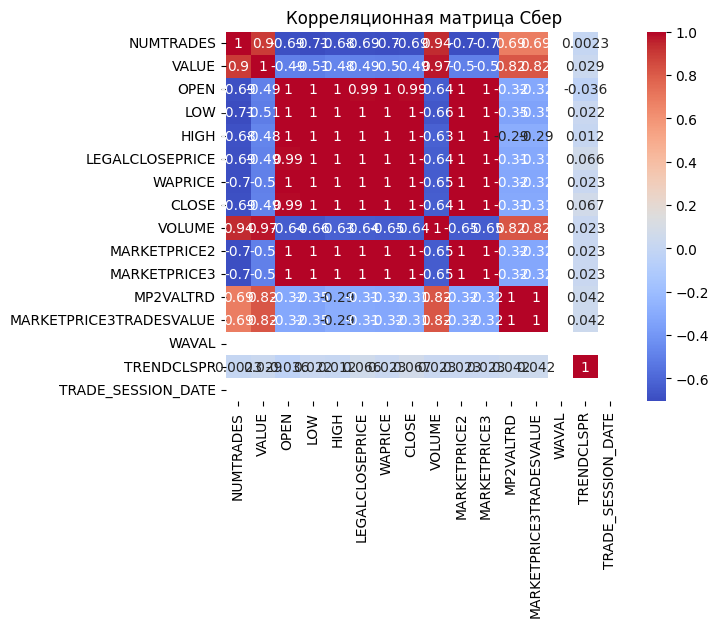

In [ ]:
# посмотрим на матрицу корреляций
correlation_matrix = df[:500].drop(['SECID', 'TRADEDATE'], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица Сбер')
plt.show()

### Функция для отбора признаков

In [ ]:
brief_df = df.loc[:, ['TRADEDATE', 'SECID','NUMTRADES', 'VALUE', 'OPEN', 'VOLUME','MP2VALTRD','MARKETPRICE3TRADESVALUE', 'TRENDCLSPR']] # получилось 9 признаков
brief_df

,TRADEDATE,SECID,NUMTRADES,VALUE,OPEN,VOLUME,MP2VALTRD,MARKETPRICE3TRADESVALUE,TRENDCLSPR
0,2013-03-25,SBER,140,5.934000e+07,96.00,593680,8.572434e+09,8.572434e+09,NaN
1,2013-03-26,SBER,183,1.260304e+08,98.58,1283550,1.221847e+10,1.221847e+10,-1.61
2,2013-03-27,SBER,176,1.218359e+08,97.90,1261950,1.251981e+10,1.251981e+10,-0.46
3,2013-03-28,SBER,299,1.924698e+08,96.38,1971410,1.257281e+10,1.257281e+10,1.90
4,2013-03-29,SBER,121,7.726886e+07,98.60,782000,2.611474e+09,2.611474e+09,0.17
...,...,...,...,...,...,...,...,...,...
3236,2026-01-16,SBER,110995,6.226817e+09,299.43,20712588,5.196432e+09,5.196432e+09,0.79
3237,2026-01-19,SBER,173094,7.942036e+09,301.67,26210423,6.332014e+09,6.332014e+09,0.70
3238,2026-01-20,SBER,100944,5.201023e+09,303.89,17136591,4.332607e+09,4.332607e+09,0.14
3239,2026-01-21,SBER,104942,8.034148e+09,304.10,26303679,6.626280e+09,6.626280e+09,0.81


Хотим прогнозировать цену - столбик OPEN. Но при этом мы знаем данные только из прошлого (нужно сдвинуть все столбики, кроме OPEN вниз на один шаг(если хотим прогнозировать след день)). Также нужно сделть вчерашнюю цену как признак. Можно также сделать не только на 1 день, но и на больший промежуток времени, но тут надо поймать баланс как-то.

In [ ]:
for c in brief_df.columns:
  for i in range(1, 8):
    brief_df[f"{c}_lag_{i}"] = brief_df[c].shift(i)

In [ ]:
brief_df.head() # Nan из-за сдвига, все ок

,TRADEDATE,SECID,NUMTRADES,VALUE,OPEN,VOLUME,MP2VALTRD,MARKETPRICE3TRADESVALUE,TRENDCLSPR,TRADEDATE_lag_1,...,MARKETPRICE3TRADESVALUE_lag_5,MARKETPRICE3TRADESVALUE_lag_6,MARKETPRICE3TRADESVALUE_lag_7,TRENDCLSPR_lag_1,TRENDCLSPR_lag_2,TRENDCLSPR_lag_3,TRENDCLSPR_lag_4,TRENDCLSPR_lag_5,TRENDCLSPR_lag_6,TRENDCLSPR_lag_7
0,2013-03-25,SBER,140,59340002.8,96.00,593680,8.572434e+09,8.572434e+09,NaN,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-03-26,SBER,183,126030358.8,98.58,1283550,1.221847e+10,1.221847e+10,-1.61,2013-03-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-03-27,SBER,176,121835900.2,97.90,1261950,1.251981e+10,1.251981e+10,-0.46,2013-03-26,...,NaN,NaN,NaN,-1.61,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-03-28,SBER,299,192469794.9,96.38,1971410,1.257281e+10,1.257281e+10,1.90,2013-03-27,...,NaN,NaN,NaN,-0.46,-1.61,NaN,NaN,NaN,NaN,NaN
4,2013-03-29,SBER,121,77268860.1,98.60,782000,2.611474e+09,2.611474e+09,0.17,2013-03-28,...,NaN,NaN,NaN,1.90,-0.46,-1.61,NaN,NaN,NaN,NaN


In [ ]:
brief_df.dtypes

,0
TRADEDATE,object
SECID,object
NUMTRADES,int64
VALUE,float64
OPEN,float64
...,...
TRENDCLSPR_lag_3,float64
TRENDCLSPR_lag_4,float64
TRENDCLSPR_lag_5,float64
TRENDCLSPR_lag_6,float64


In [ ]:
brief_df['TRADEDATE'] = pd.to_datetime(brief_df['TRADEDATE'])
brief_df.head()

,TRADEDATE,SECID,NUMTRADES,VALUE,OPEN,VOLUME,MP2VALTRD,MARKETPRICE3TRADESVALUE,TRENDCLSPR,TRADEDATE_lag_1,...,MARKETPRICE3TRADESVALUE_lag_5,MARKETPRICE3TRADESVALUE_lag_6,MARKETPRICE3TRADESVALUE_lag_7,TRENDCLSPR_lag_1,TRENDCLSPR_lag_2,TRENDCLSPR_lag_3,TRENDCLSPR_lag_4,TRENDCLSPR_lag_5,TRENDCLSPR_lag_6,TRENDCLSPR_lag_7
0,2013-03-25,SBER,140,59340002.8,96.00,593680,8.572434e+09,8.572434e+09,NaN,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-03-26,SBER,183,126030358.8,98.58,1283550,1.221847e+10,1.221847e+10,-1.61,2013-03-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-03-27,SBER,176,121835900.2,97.90,1261950,1.251981e+10,1.251981e+10,-0.46,2013-03-26,...,NaN,NaN,NaN,-1.61,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-03-28,SBER,299,192469794.9,96.38,1971410,1.257281e+10,1.257281e+10,1.90,2013-03-27,...,NaN,NaN,NaN,-0.46,-1.61,NaN,NaN,NaN,NaN,NaN
4,2013-03-29,SBER,121,77268860.1,98.60,782000,2.611474e+09,2.611474e+09,0.17,2013-03-28,...,NaN,NaN,NaN,1.90,-0.46,-1.61,NaN,NaN,NaN,NaN


## Визуализация

### Изменение цены

/tmp/ipython-input-1814508200.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_price = df.groupby(pd.Grouper(key='TRADEDATE', freq='M'))['OPEN'].mean().reset_index()
/tmp/ipython-input-1814508200.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_trades = df.groupby(pd.Grouper(key='TRADEDATE', freq='M'))['NUMTRADES'].mean().reset_index()


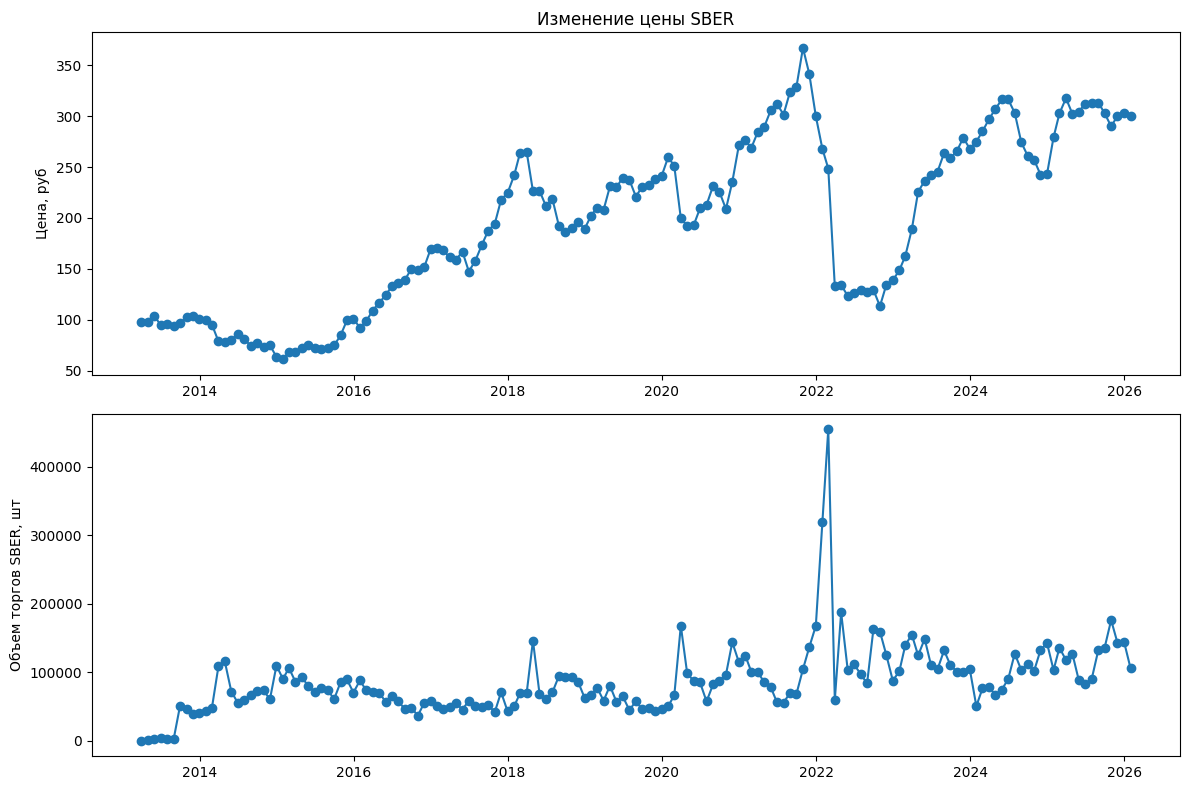

In [ ]:
import matplotlib.pyplot as plt
def visual(df):
  # Преобразование approval_date в datetime и сортировка
  df.sort_values(by='TRADEDATE', inplace=True)

  # Группировка по месяцам и расчет среднего значения
  monthly_avg_price = df.groupby(pd.Grouper(key='TRADEDATE', freq='M'))['OPEN'].mean().reset_index()
  monthly_avg_trades = df.groupby(pd.Grouper(key='TRADEDATE', freq='M'))['NUMTRADES'].mean().reset_index()

  # Создание графика
  plt.figure(figsize=(12, 8))
  ax1 = plt.subplot(211)
  ax1.plot(monthly_avg_price['TRADEDATE'], monthly_avg_price['OPEN'], marker='o')
  ax1.set_title(f'Изменение цены {df["SECID"][0]}')
  ax1.set_ylabel('Цена, руб')

  ax2 = plt.subplot(212, sharex=ax1)
  ax2.plot(monthly_avg_trades['TRADEDATE'], monthly_avg_trades['NUMTRADES'], marker='o')

  ax2.set_ylabel(f'Объем торгов {df["SECID"][0]}, шт')

  plt.tight_layout()
  plt.show()
visual(brief_df)

# Candles - более маленькие tf

In [ ]:
import requests
import json

url = "https://iss.moex.com/iss/engines/stock/markets/shares/boards/tqbr/securities/SBER/candles.json"

params = {
    "interval": 24,        # 1, 10 минут, 24 часа
    "from": "2014-01-01",
    "till": "2014-01-11",
    "start": 0
}

response = requests.get(url, params=params)
data = response.json()

data["candles"]["data"]


[[100.2,
  98.91,
  100.31,
  98.62,
  3154470383.9,
  31691800,
  '2014-01-06 00:00:00',
  '2014-01-06 23:59:59'],
 [99.1,
  98.19,
  99.41,
  97.85,
  4179938515.5,
  42372290,
  '2014-01-08 00:00:00',
  '2014-01-08 23:59:59'],
 [98.44,
  98,
  98.77,
  97.69,
  4518388781.2,
  45986900,
  '2014-01-09 00:00:00',
  '2014-01-09 23:59:59'],
 [97.87,
  99.2,
  99.41,
  97.52,
  5109679480.9,
  51902400,
  '2014-01-10 00:00:00',
  '2014-01-10 23:59:59']]

Каждая свеча:
[
  open,
  close,
  high,
  low,
  value(объём в штуках акций),
  volume(оборот в рублях),
  begin,
  end
]

In [ ]:
len(data["candles"]["data"])# видим ограничение - максимум 500

500

### парсинг 1d с 2014

In [ ]:
import requests
import time
import pandas as pd

def load_daily_candles(
    security: str,
    date_from: str,
    date_till: str,
    sleep: float = 0.2
):
    url = f"https://iss.moex.com/iss/engines/stock/markets/shares/boards/tqbr/securities/{security}/candles.json"

    start = 0
    step = 500
    all_rows = []

    while True:
        params = {
            "interval": 24,     # дневные свечи
            "from": date_from,
            "till": date_till,
            "start": start
        }

        r = requests.get(url, params=params)
        r.raise_for_status()
        data = r.json()

        rows = data["candles"]["data"]

        if not rows:
            break

        all_rows.extend(rows)
        start += step
        time.sleep(sleep)

    return all_rows


In [ ]:
rows = load_daily_candles(
    security="SBER",
    date_from="2014-01-01",
    date_till="2026-01-20"
)

len(rows)


3090

In [ ]:
columns = [
    "open",
    "close",
    "high",
    "low",
    "value",
    "volume",
    "begin",
    "end"
]

df = pd.DataFrame(rows, columns=columns)

df["begin"] = pd.to_datetime(df["begin"])
df.set_index("begin", inplace=True)

df.sort_index(inplace=True)


In [ ]:
df

,open,close,high,low,value,volume,end
begin,,,,,,,
2014-01-06,100.20,98.91,100.31,98.62,3.154470e+09,31691800,2014-01-06 23:59:59
2014-01-08,99.10,98.19,99.41,97.85,4.179939e+09,42372290,2014-01-08 23:59:59
2014-01-09,98.44,98.00,98.77,97.69,4.518389e+09,45986900,2014-01-09 23:59:59
2014-01-10,97.87,99.20,99.41,97.52,5.109679e+09,51902400,2014-01-10 23:59:59
2014-01-13,99.30,100.25,100.35,99.04,6.191507e+09,62051250,2014-01-13 23:59:59
...,...,...,...,...,...,...,...
2026-01-16,299.43,301.52,301.97,298.90,6.226817e+09,20712588,2026-01-16 23:59:59
2026-01-17,301.67,301.28,301.89,301.00,3.198462e+08,1061595,2026-01-17 23:59:59
2026-01-18,301.28,301.86,301.89,301.10,2.594349e+08,860536,2026-01-18 23:59:57


In [ ]:
# df.to_csv("/content/drive/MyDrive/ВКР/data/sber_1d_2014_2026.csv")

In [ ]:
# df.to_parquet("/content/drive/MyDrive/ВКР/data/sber_1d_2014_2026.parquet")

## парсинг **1h** два года

In [ ]:
import requests
import time
import pandas as pd

def load_hourly_candles(
    security: str,
    date_from: str,
    date_till: str,
    sleep: float = 0.2
):
    """
    Загружает часовые свечи (interval=60) через MOEX ISS API
    """
    url = f"https://iss.moex.com/iss/engines/stock/markets/shares/boards/tqbr/securities/{security}/candles.json"

    start = 0
    step = 500
    all_rows = []

    while True:
        params = {
            "interval": 60,     # часовые свечи
            "from": date_from,
            "till": date_till,
            "start": start
        }

        r = requests.get(url, params=params)
        r.raise_for_status()
        data = r.json()

        rows = data["candles"]["data"]

        if not rows:
            break

        all_rows.extend(rows)
        start += step
        time.sleep(sleep)

    return all_rows

In [ ]:
rows = load_hourly_candles(
    security="SBER",
    date_from="2024-01-01",
    date_till="2026-01-20"
)

In [ ]:
print(f"Загружено {len(rows)} свечей")

Загружено 9208 свечей


In [ ]:
# Преобразуем в DataFrame
columns = ["open", "close", "high", "low", "value", "volume", "begin", "end"]
df = pd.DataFrame(rows, columns=columns)

# Устанавливаем индекс времени
df["begin"] = pd.to_datetime(df["begin"])
df.set_index("begin", inplace=True)
df.sort_index(inplace=True)

In [ ]:
df

,open,close,high,low,value,volume,end
begin,,,,,,,
2024-01-03 09:00:00,271.90,271.90,271.90,271.90,4.825137e+07,177460,2024-01-03 09:59:59
2024-01-03 10:00:00,271.75,273.48,273.70,271.00,1.430393e+09,5248430,2024-01-03 10:59:59
2024-01-03 11:00:00,273.49,273.93,274.36,273.48,9.107096e+08,3324750,2024-01-03 11:59:59
2024-01-03 12:00:00,273.93,273.70,273.95,273.09,6.086286e+08,2225570,2024-01-03 12:59:59
2024-01-03 13:00:00,273.70,273.72,274.20,273.25,4.514253e+08,1648780,2024-01-03 13:59:59
...,...,...,...,...,...,...,...
2026-01-20 19:00:00,303.85,303.86,304.14,303.62,1.236033e+08,406677,2026-01-20 19:59:59
2026-01-20 20:00:00,303.86,303.87,303.95,303.74,4.032604e+07,132711,2026-01-20 20:59:59
2026-01-20 21:00:00,303.87,304.08,304.30,303.73,1.073702e+08,353080,2026-01-20 21:59:59


In [ ]:
# Сохраняем
# df.to_csv("/content/drive/MyDrive/ВКР/data/sber_1h_2024_2026.csv")
# df.to_parquet("/content/drive/MyDrive/ВКР/data/sber_1h_2024_2026.parquet")

## парсинг 10m с 07.25 до 01.26


In [ ]:
import requests
import time
import pandas as pd

def load_minute_candles(
    security: str,
    date_from: str,
    date_till: str,
    sleep: float = 0.2
):
    """
    Загружает минутные свечи (interval=1) через MOEX ISS API
    """
    url = f"https://iss.moex.com/iss/engines/stock/markets/shares/boards/tqbr/securities/{security}/candles.json"

    start = 0
    step = 500
    all_rows = []

    while True:
        params = {
            "interval": 10,     # 10-минутные свечи
            "from": date_from,
            "till": date_till,
            "start": start
        }

        r = requests.get(url, params=params)
        r.raise_for_status()
        data = r.json()

        rows = data["candles"]["data"]

        if not rows:
            break

        all_rows.extend(rows)
        start += step
        time.sleep(sleep)

    return all_rows

In [ ]:
rows = load_minute_candles(
    security="SBER",
    date_from="2025-07-01",
    date_till="2026-01-20"
)

print(f"Загружено {len(rows)} минутных свечей")

Загружено 16514 минутных свечей


In [ ]:
# Преобразуем в DataFrame
columns = ["open", "close", "high", "low", "value", "volume", "begin", "end"]
df = pd.DataFrame(rows, columns=columns)

# Устанавливаем индекс времени
df["begin"] = pd.to_datetime(df["begin"])
df.set_index("begin", inplace=True)
df.sort_index(inplace=True)

In [ ]:
df

,open,close,high,low,value,volume,end
begin,,,,,,,
2025-07-01 06:50:00,316.69,316.69,316.69,316.69,2805873.40,8860,2025-07-01 06:59:59
2025-07-01 07:00:00,316.64,316.72,316.72,316.30,19887196.10,62820,2025-07-01 07:09:59
2025-07-01 07:10:00,316.72,316.85,316.86,316.66,14751946.80,46570,2025-07-01 07:19:59
2025-07-01 07:20:00,316.83,316.92,316.99,316.80,25906007.90,81750,2025-07-01 07:29:59
2025-07-01 07:30:00,316.91,316.79,316.95,316.77,30578130.80,96500,2025-07-01 07:39:59
...,...,...,...,...,...,...,...
2026-01-20 23:00:00,304.33,304.21,304.33,304.13,25375657.93,83400,2026-01-20 23:09:59
2026-01-20 23:10:00,304.20,303.97,304.25,303.95,19567628.59,64359,2026-01-20 23:19:59
2026-01-20 23:20:00,303.97,304.03,304.06,303.95,3878124.95,12757,2026-01-20 23:29:59


In [ ]:
# df.to_csv("/content/drive/MyDrive/ВКР/data/sber_10m_07-2025_2026.csv")
# df.to_parquet("/content/drive/MyDrive/ВКР/data/sber_10m_07-2025_2026.parquet")

в общем котировки умеем парсить, нужно разобраться с новостями и все будет хорошо!